# <a id='toc1_'></a>Shallow Neural Networks [\[shallow-neural-networks\]](https://www.geeksforgeeks.org/deep-learning/shallow-neural-networks/)<br>

## <a id='toc1_1_'></a>MULTI LAYER PERCEPTRON (MLP) [\[MLP-machinelearningmastery\]](https://machinelearningmastery.com/how-to-develop-multilayer-perceptron-models-for-time-series-forecasting/) [&#8593;](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [MULTI LAYER PERCEPTRON (MLP) \[MLP-machinelearningmastery\]](#toc1_1_)    
  - [Import + upload + preprocessing](#toc1_2_)    
      - [Divisione in train e test set](#toc1_2_1_1_)    
  - [Data augmentation](#toc1_3_)    
  - [Scaling](#toc1_4_)    
  - [Sliding window](#toc1_5_)    
  - [Definition and training of an MLP shallow neural network](#toc1_6_)    
      - [La Regolarizzazione (Evitare l'Overfitting)](#toc1_6_1_1_)    
      - [Come impara il modello](#toc1_6_1_2_)    
    - [Riassunto flusso](#toc1_6_2_)    
  - [Tentativo con valori differenziati](#toc1_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_2_'></a>[Import + upload + preprocessing](#toc0_)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import src.utils as utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session
import os
import random
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [5]:
df = utils.load_data()
display(df.head())

Dataset caricato: 65 anni, 29 variabili.


AttributeError: 'NoneType' object has no attribute 'head'

In [36]:
target = df[['Year', 'Rural population (% of total population)']].copy()
target.columns = ['Year', 'Value']
display(target.head())

,Year,Value
0,1960,40.639
1,1961,40.144
2,1962,39.645
3,1963,39.147
4,1964,38.650


#### <a id='toc1_2_1_1_'></a>[Divisione in train e test set](#toc0_)

I divide raw time series in train and test set, with 80:20 ratio --> tot 65 = train 52 + test 13 <br>
I extract specific series for augmentation --> x_train_vals = Year values + y_train_vals = Value values

In [1]:
split_idx = int(len(target) * 0.8)
train_raw = target.iloc[:split_idx]
test_raw = target.iloc[split_idx:]

x_train_vals = train_raw['Year'].values
y_train_vals = train_raw['Value'].values

NameError: name 'target' is not defined

## <a id='toc1_3_'></a>[Data augmentation](#toc0_)

[Time Series Data Augmentation for Deep Learning: A Survey](https://arxiv.org/abs/2002.12478)

Noise injection is a method by injecting small amount
of noise/outlier into time series without changing the corresponding labels. This includes injecting Gaussian noise,
spike, step-like trend, and slope-like trend, etc.

[Time series forecasting using a hybrid ARIMA and neural network model](https://www.sciencedirect.com/science/article/pii/S0925231201007020)
Although ARIMA models are quite flexible in that they can represent several different types of time series, i.e., pure autoregressive (AR), pure moving average (MA) and combined AR and MA (ARMA) series, their major limitation is the pre-assumed linear form of the model. That is, a linear correlation structure is assumed among the time series values and therefore, no nonlinear patterns can be captured by the ARIMA model. 

Many empirical studies including several large-scale forecasting competitions suggest that by combining several different models, forecasting accuracy can often be improved over the individual model without the need to find the “true” or “best” model

In [39]:
def augment_step_function(x, y, scale_factor):
    """
    Augments data points of initial time serie by scale_factor times

    Args:
        x (_type_): first sequence to be interpolated ['Year']
        y (_type_): second sequence to be interpolated ['Value']
        scale_factor (int): by how many points the time serie have to be augmented

    Returns:
        DataFrame{'Year', 'Value'}: df with columns of Year and Value interpolated by scale_factor
    """
    
    # 'kind=previous' mantiene il valore precedente (comportamento a gradino)
    f = interp1d(x, y, kind='previous', fill_value="extrapolate")
    x_step = np.linspace(x.min(), x.max(), len(x) * scale_factor)
    y_step = f(x_step)
    return pd.DataFrame({'Year': x_step, 'Value': y_step})

In [40]:
def augment_linear_with_jitter(x, y, scale_factor, noise_level):
    """
    Creates new data points by interpolation = tracing a line between existing data points
    and adds jittering = casual noise for resilience

    Args:
        x (_type_): first sequence to be interpolated ['Year']
        y (_type_): second sequence to be interpolated ['Value']
        scale_factor (int): by how many points the time serie have to be augmented
        noise_level (float): standard deviation of noise (0.01 = 1% variation)

    Returns:
        DataFrame{'Year', 'Value'}: df with columns of Year and Value interpolated by scale_factor
    """
    f = interp1d(x, y, kind='linear', fill_value="extrapolate")
    x_interp = np.linspace(x.min(), x.max(), len(x) * scale_factor)
    y_interp = f(x_interp)
    
    noise = np.random.normal(loc=0.0, scale=noise_level, size=y_interp.shape)
    y_new = y_interp + noise
    return pd.DataFrame({'Year': x_interp, 'Value': y_new})

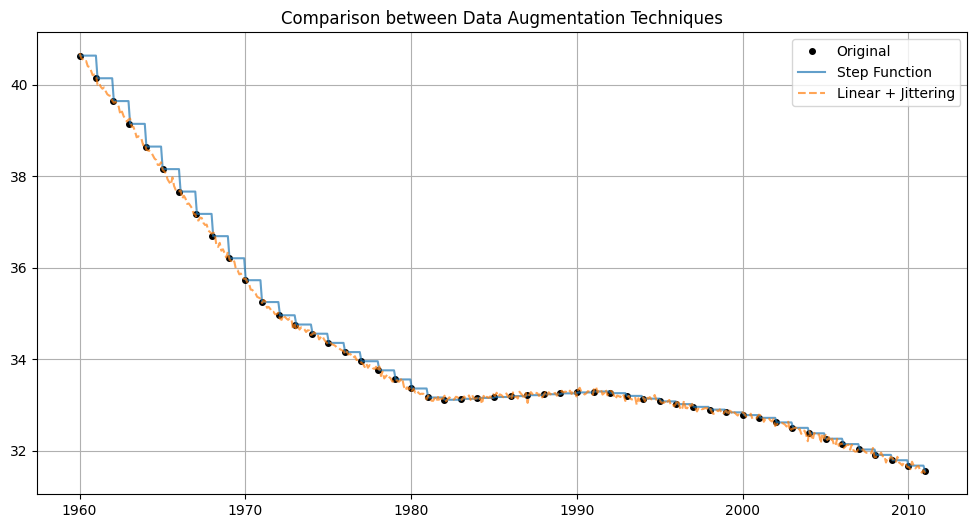

In [41]:
df_step = augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
df_jitter = augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
df_step_u = df_step.drop_duplicates(subset='Year')
df_jitter_u = df_jitter.drop_duplicates(subset='Year')

plt.figure(figsize=(12, 6))
plt.plot(x_train_vals, y_train_vals, '.', label='Original', color='black', markersize=8)
plt.plot(df_step['Year'], df_step['Value'], '-', label='Step Function', alpha=0.7)
plt.plot(df_jitter['Year'], df_jitter['Value'], '--', label='Linear + Jittering', alpha=0.7)
plt.title("Comparison between Data Augmentation Techniques")
plt.legend()
plt.grid(True)
plt.show()

## <a id='toc1_4_'></a>[Scaling](#toc0_)

I create a MinMaxScaler between 0,1. <br>
I reshape between -1, 1 because scikit-learn (which provides the scaler) requires 2D matrices (samples, features). 
[attualmente sto facendo scaling sulla colonna dei valori, quindi ha una sola dimensione perchè ho droppato gli anni.]
<br> 
I do the scaling on:
- original train set,
- step function augmented train set,
- linear interpolation with jittering augmented train set,
- original test set 

In [42]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(y_train_vals.reshape(-1, 1))

train_norm_orig = scaler.transform(y_train_vals.reshape(-1, 1))
train_norm_step = scaler.transform(df_step['Value'].values.reshape(-1, 1))
train_norm_jitter = scaler.transform(df_jitter['Value'].values.reshape(-1, 1))
test_norm = scaler.transform(test_raw['Value'].values.reshape(-1, 1))

## <a id='toc1_5_'></a>[Sliding window](#toc0_)

In [43]:
def create_sliding_window(data, window_size, HORIZON):
    """
    Transforms a univariate time series into a supervised dataset (X, y)

    Parametri:
    - data (np.array): array NumPy 1D containing scaled time series.
    - window_size (int): number of past temporal step  Numero di step temporali passati da usare come input (X).
    - HORIZON (int): Distanza nel futuro del target da predire (default=1, cioè lo step successivo).

    Ritorna:
    - X (np.array): input features matrix (samples, window_size).
    - y (np.array): samples array (samples).
    """
    X, y = [], []
    
    # Iteriamo attraverso la serie fino a quando c'è abbastanza spazio per la finestra + target
    for i in range(len(data) - window_size - HORIZON + 1):
        # Estraiamo la finestra di input (dal punto i al punto i + window_size)
        seq = data[i:(i + window_size), 0]
        
        # Estraiamo il target (il punto esattamente dopo la finestra, o più avanti se HORIZON > 1)
        target = data[i + window_size + HORIZON - 1, 0]
        
        X.append(seq)
        y.append(target)
        
    return np.array(X), np.array(y)

In [44]:
WINDOW_SIZE = 5
HORIZON = 1

X_train_orig, y_train_orig = create_sliding_window(train_norm_orig, WINDOW_SIZE, HORIZON)
X_train_step, y_train_step = create_sliding_window(train_norm_step, WINDOW_SIZE, HORIZON)
X_train_jitter, y_train_jitter = create_sliding_window(train_norm_jitter, WINDOW_SIZE, HORIZON)

X_test, y_test = create_sliding_window(test_norm, WINDOW_SIZE, HORIZON)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Dimensioni Input Rete Neurale:")
print(f"Original: {X_train_orig.shape}")
print(f"Step:     {X_train_step.shape}")
print(f"Jitter:   {X_train_jitter.shape}")
print(f"Test Set: {X_test.shape}")

Dimensioni Input Rete Neurale:
Original: (47, 5)
Step:     (515, 5)
Jitter:   (515, 5)
Test Set: (8, 5)


<a class="anchor" id="training"> </a>
## <a id='toc1_6_'></a>[Definition and training of an MLP shallow neural network](#toc0_)

> Struttura
* **`Sequential`**: È il contenitore del modello. Significa che i layer sono impilati uno sopra l'altro in sequenza: l'output del primo diventa l'input del secondo, e così via.
* **`Input(shape=(input_dim,))`**: Definisce la forma dei dati in ingresso.
    * `input_dim`: È una variabile (probabilmente un numero intero, come 5 o 10) che indica quante caratteristiche (features) ha ogni campione di dati.

> I Layer "Dense" (Densi)
* **`Dense`**: È il tipo di layer più comune (Fully Connected). Significa che **ogni** neurone di questo layer è collegato a **tutti** i neuroni del layer precedente.
* **`16` / `8` / `1`**: È il numero di neuroni (unità) presenti in quel layer specifico. Più neuroni ci sono, più complessi sono i pattern che il modello può imparare (ma aumenta il rischio di memorizzare i dati invece di capirli).
* **`activation='tanh'`**: È la **Funzione di Attivazione**. Decide se e quanto un neurone deve "attivarsi".
    * *tanh (Tangente Iperbolica)*: Trasforma qualsiasi valore in uscita in un numero compreso tra **-1 e 1**. È utile quando i dati possono avere valori negativi significativi.
* **`activation='linear'`**: Usata nell'ultimo layer. Non trasforma il dato. Restituisce il valore puro calcolato. È tipico dei problemi di **regressione** (dove devi predire un numero esatto, es. prezzo, temperatura).


In [45]:
def build_mlp_model(input_dim):
    """ Crea un modello MLP con un layer di input, due hidden layer, con rispettivamente 32 e 16 neuroni e un layer di output

    Args:
        input_dim (int): _description_

    Returns:
        model: _description_
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='tanh'),
        Dropout(0.1),
        Dense(16, activation='tanh'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

In [46]:
def reset_seeds(seed_value=42):
    """
    Resetta tutti i generatori di numeri casuali per garantire
    che il training dia sempre lo stesso risultato.
    """
    clear_session()
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    tf.config.experimental.enable_op_determinism() 

In [47]:
def plot_results(df_res, results):
    plt.figure(figsize=(14, 7))
    steps = range(len(y_test_real))
    plt.plot(steps, y_test_real, 'o-', label='REALE', color='black', linewidth=2.5)

    colors = ['red', 'green', 'blue']
    for i, (name, preds) in enumerate(results.items()):
        plt.plot(steps, preds, '--', label=f'{name} (RMSE: {df_res[df_res.Dataset==name].RMSE.values[0]:.2f})', color=colors[i])

    plt.title("Comparison Performance MLP")
    plt.xlabel("Anni Futuri")
    plt.ylabel("Valore Reale")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

INIZIO TRAINING ROBUSTO (Seed=42)


Training su: Originale (Samples: 47)
Terminato. RMSE: 0.1601 | Epoche usate: 40

Training su: Step Function (Samples: 515)
Terminato. RMSE: 0.0716 | Epoche usate: 21

Training su: Linear + Jitter (Samples: 515)
Terminato. RMSE: 0.0459 | Epoche usate: 19


,Dataset,RMSE,MAE,Epoche
2,Linear + Jitter,0.045876,0.040936,19
1,Step Function,0.071630,0.071105,21
0,Originale,0.160140,0.156890,40


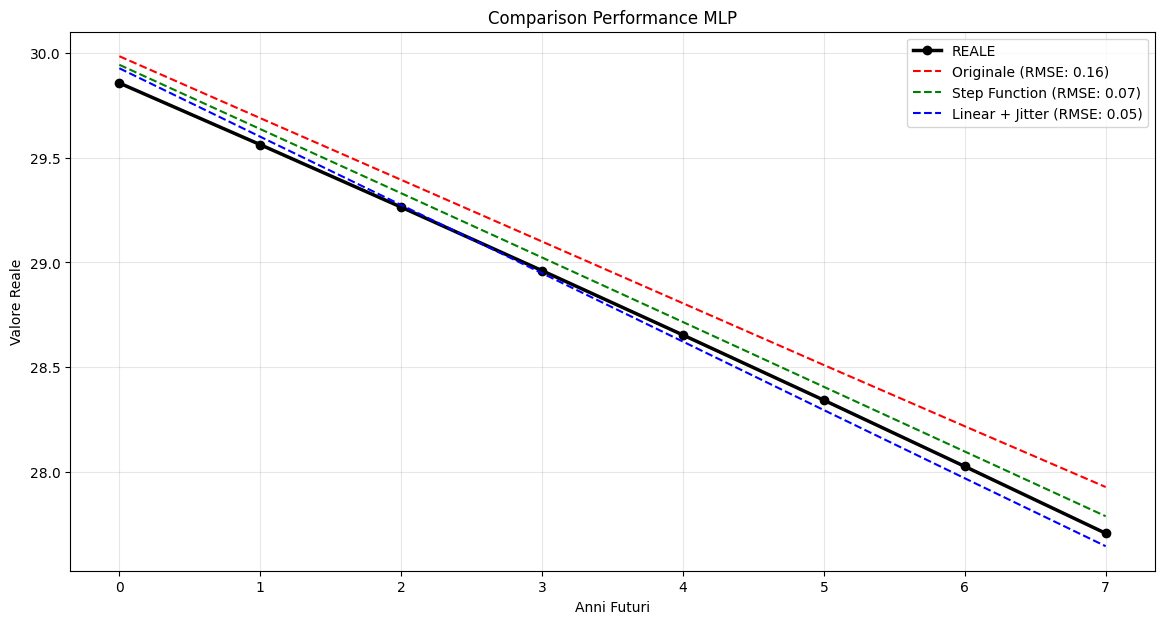

In [48]:
training_sets = {
    "Originale": (X_train_orig, y_train_orig),
    "Step Function": (X_train_step, y_train_step),
    "Linear + Jitter": (X_train_jitter, y_train_jitter)
}

results = {}
metrics_list = []

BATCH_SIZE = 16
EPOCHS = 200
input_dim = WINDOW_SIZE

# CALLBACKS AVANZATI
# Early Stopping: si ferma se non migliora
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, # alla fine ripristina i pesi migliori, non gli ultimi
    verbose=0
)

# Reduce LR: se l'errore non scende, riduce la velocità di apprendimento
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=0.00001,
    verbose=0
)

print(f"INIZIO TRAINING ROBUSTO (Seed=42)")
for name, (curr_X, curr_y) in training_sets.items():
    
    # resettiamo seed prima di ogni modello, così ogni modello parte dalle stesse condizioni
    reset_seeds(42)
    
    print(f"\nTraining su: {name} (Samples: {len(curr_X)})")
    
    # Costruiamo il modello (ora i pesi iniziali saranno sempre identici grazie al reset)
    model = build_mlp_model(input_dim)
    
    # Fit del modello
    # Nota: usiamo validation_data=(X_test, y_test) per monitorare l'overfitting in tempo reale
    history = model.fit(
        curr_X, curr_y,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test), # Usiamo il test per guidare l'Early Stopping
        verbose=0,
        callbacks=[early_stop, reduce_lr],
        shuffle=True 
    )
    
    # Predizione
    pred_scaled = model.predict(X_test, verbose=0)
    pred_real = scaler.inverse_transform(pred_scaled)
    
    # Calcolo Metriche
    rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
    mae = mean_absolute_error(y_test_real, pred_real)
    
    results[name] = pred_real
    metrics_list.append({
        "Dataset": name, 
        "RMSE": rmse, 
        "MAE": mae, 
        "Epoche": len(history.history['loss'])
    })
    
    print(f"Terminato. RMSE: {rmse:.4f} | Epoche usate: {len(history.history['loss'])}")

df_res = pd.DataFrame(metrics_list).sort_values(by="RMSE")
display(df_res)
plot_results(df_res, results)

INIZIO TRAINING ENSEMBLE (5 run per dataset)

Dataset: Originale
   Run 1/5 (Seed 42) -> RMSE: 1.4861
   Run 2/5 (Seed 123) -> RMSE: 1.6013
   Run 3/5 (Seed 456) -> RMSE: 2.7458
   Run 4/5 (Seed 789) -> RMSE: 1.0204
   Run 5/5 (Seed 1000) -> RMSE: 1.0681
   >>> ENSEMBLE RMSE: 1.5822 (Molto più stabile!)

Dataset: Step Function
   Run 1/5 (Seed 42) -> RMSE: 0.0308
   Run 2/5 (Seed 123) -> RMSE: 0.6853
   Run 3/5 (Seed 456) -> RMSE: 0.9379
   Run 4/5 (Seed 789) -> RMSE: 0.4982
   Run 5/5 (Seed 1000) -> RMSE: 0.2060
   >>> ENSEMBLE RMSE: 0.4010 (Molto più stabile!)

Dataset: Linear + Jitter
   Run 1/5 (Seed 42) -> RMSE: 0.2427
   Run 2/5 (Seed 123) -> RMSE: 0.7184
   Run 3/5 (Seed 456) -> RMSE: 0.9619
   Run 4/5 (Seed 789) -> RMSE: 0.5479
   Run 5/5 (Seed 1000) -> RMSE: 0.1247
   >>> ENSEMBLE RMSE: 0.4902 (Molto più stabile!)


,Dataset,RMSE Ensemble,MAE Ensemble
1,Step Function,0.400979,0.396946
2,Linear + Jitter,0.490248,0.489051
0,Originale,1.582201,1.563142


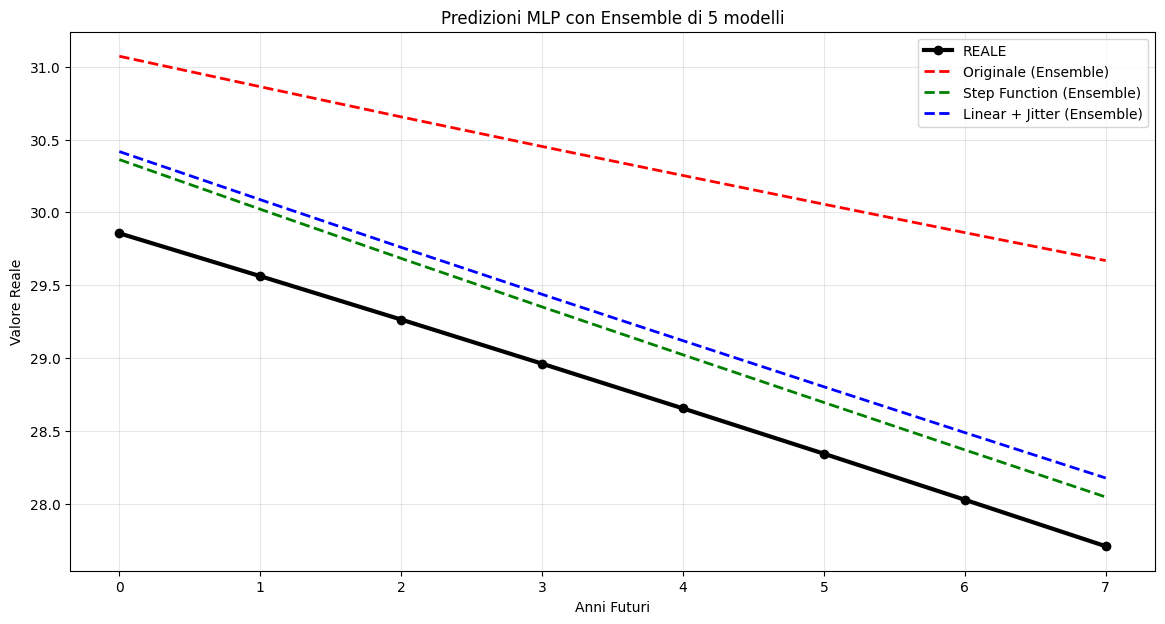

In [49]:
N_RUNS = 5  # Quanti modelli addestrare per ogni dataset (es. 5)
seeds = [42, 123, 456, 789, 1000] # Lista di seed fissi per riproducibilità

results_ensemble = {}
metrics_ensemble = []

print(f"INIZIO TRAINING ENSEMBLE ({N_RUNS} run per dataset)")

for name, (curr_X, curr_y) in training_sets.items():
    print(f"\nDataset: {name}")
    
    # Matrice per salvare tutte le predizioni di questo dataset: shape (N_RUNS, n_test_points)
    all_predictions = np.zeros((N_RUNS, len(X_test)))
    
    for i in range(N_RUNS):
        # 1. Reset Seed specifico per questa run
        current_seed = seeds[i]
        reset_seeds(current_seed) 
        
        # 2. Costruisci e Addestra
        model = build_mlp_model(input_dim)
        history = model.fit(
            curr_X, curr_y,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(X_test, y_test),
            verbose=0,
            callbacks=[early_stop, reduce_lr],
            shuffle=True
        )
        
        # 3. Predici
        pred_scaled = model.predict(X_test, verbose=0)
        pred_real = scaler.inverse_transform(pred_scaled).flatten()
        
        # Salva la predizione nella matrice
        all_predictions[i, :] = pred_real
        print(f"   Run {i+1}/{N_RUNS} (Seed {current_seed}) -> RMSE: {np.sqrt(mean_squared_error(y_test_real, pred_real)):.4f}")

    # 4. CALCOLA LA MEDIA DELL'ENSEMBLE (La predizione robusta)
    ensemble_pred = np.mean(all_predictions, axis=0)
    
    # 5. Calcola metriche sulla media
    rmse_ens = np.sqrt(mean_squared_error(y_test_real, ensemble_pred))
    mae_ens = mean_absolute_error(y_test_real, ensemble_pred)
    
    results_ensemble[name] = ensemble_pred
    metrics_ensemble.append({
        "Dataset": name, 
        "RMSE Ensemble": rmse_ens, 
        "MAE Ensemble": mae_ens
    })
    
    print(f"   >>> ENSEMBLE RMSE: {rmse_ens:.4f} (Molto più stabile!)")

# --- VISUALIZZAZIONE FINALE ---
df_res_ens = pd.DataFrame(metrics_ensemble).sort_values(by="RMSE Ensemble")
display(df_res_ens)

plt.figure(figsize=(14, 7))
steps = range(len(y_test_real))
plt.plot(steps, y_test_real, 'o-', label='REALE', color='black', linewidth=3)

colors = ['red', 'green', 'blue']
for i, (name, preds) in enumerate(results_ensemble.items()):
    plt.plot(steps, preds, '--', label=f'{name} (Ensemble)', color=colors[i], linewidth=2)

plt.title(f"Predizioni MLP con Ensemble di {N_RUNS} modelli")
plt.xlabel("Anni Futuri")
plt.ylabel("Valore Reale")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se contiamo i layer che contengono "neuroni" e che apprendono dai dati (cioè quelli che hanno dei **pesi** da addestrare), il tuo modello ha **3 layer**.

Nello specifico:
1.  Primo Hidden Layer (`Dense`) con 16 neuroni.
2.  Secondo Hidden Layer (`Dense`) con 8 neuroni.
3.  Output Layer (`Dense`) con 1 neurone.

Se invece consideriamo la struttura tecnica di Keras (ogni operazione è un layer), ce ne sono **4** nel blocco `Sequential` (i 3 Dense + 1 Dropout), più la definizione dell'Input.


#### <a id='toc1_6_1_1_'></a>[La Regolarizzazione (Evitare l'Overfitting)](#toc0_)
Queste tecniche servono a impedire che il modello impari "a memoria" i dati di training (Overfitting).

* **`kernel_regularizer=l2(0.01)`**: Applica una penalità matematica (Ridge Regression) se i pesi del modello diventano troppo grandi. Mantiene il modello "stabile" e meno sensibile a piccoli disturbi nei dati.
* **`Dropout(0.2)`**: Durante l'addestramento, questo layer "spegne" (mette a zero) casualmente il **20%** dei neuroni ad ogni passaggio. Questo costringe la rete a non affidarsi troppo a singoli neuroni, rendendola più robusta.

#### <a id='toc1_6_1_2_'></a>[Come impara il modello](#toc0_)
* **`model.compile`**: Configura il processo di apprendimento prima di iniziare.
* **`optimizer=Adam`**: È l'algoritmo che aggiorna i pesi della rete. *Adam* è uno dei più usati perché adatta la velocità di apprendimento automaticamente.
* **`learning_rate=0.001`**: È la "lunghezza del passo" che l'ottimizzatore fa quando corregge gli errori.
    * Troppo alto: il modello non converge mai.
    * Troppo basso: il modello impiega un'eternità a imparare.
* **`loss='mse'`**: Sta per **Mean Squared Error** (Errore Quadratico Medio). È la "pagella" del modello: misura quanto le previsioni del modello sono lontane dai valori reali. L'obiettivo dell'addestramento è rendere questo numero il più basso possibile.

### <a id='toc1_6_2_'></a>[Riassunto flusso](#toc0_)
-> input <br>
-> 16 neuroni (con regolarizzazione L2) <br>
-> "dimentica" casualmente il 20% delle informazioni (Dropout) <br>
-> raffina il risultato con 8 neuroni <br>
-> 1 numero finale come predizione.

## <a id='toc1_7_'></a>[Tentativo con valori differenziati](#toc0_)

In [50]:
def make_diff(data):
    """Calcola la differenza tra t e t-1. L'array risultante ha lunghezza N-1."""
    return np.diff(data, axis=0)

def inverse_diff(last_real_value, pred_diff):
    """
    Ricostruisce il valore reale sommando la differenza predetta 
    all'ultimo valore reale conosciuto.
    """
    return last_real_value + pred_diff

In [51]:
diff_train_orig = make_diff(y_train_vals)
diff_train_step = make_diff(df_step['Value'].values)
diff_train_jitter = make_diff(df_jitter['Value'].values)

y_test_vals = test_raw['Value'].values
diff_test = make_diff(y_test_vals) 

In [52]:
# Scaling (range -1, 1 perché le differenze possono essere negative)
scaler_diff = MinMaxScaler(feature_range=(-1, 1))
scaler_diff.fit(diff_train_orig.reshape(-1, 1)) # Fit solo sull'originale come sempre

,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [53]:
# Sliding Window
WINDOW_SIZE = 5
HORIZON = 1

# Helper per creare tutto in un colpo solo
def prepare_diff_dataset(raw_diff_data):
    norm = scaler_diff.transform(raw_diff_data.reshape(-1, 1))
    X, y = create_sliding_window(norm, WINDOW_SIZE, HORIZON)
    return X, y

X_diff_orig, y_diff_orig = prepare_diff_dataset(diff_train_orig)
X_diff_step, y_diff_step = prepare_diff_dataset(diff_train_step)
X_diff_jitter, y_diff_jitter = prepare_diff_dataset(diff_train_jitter)

# Test set differenziato (per monitorare la loss)
X_diff_test, y_diff_test = prepare_diff_dataset(diff_test)

print(f"Dati differenziati pronti. Esempio shape: {X_diff_orig.shape}")

Dati differenziati pronti. Esempio shape: (46, 5)


--- TRAINING SU DATI DIFFERENZIATI ---

>> Dataset: Diff Originale
   RMSE Ricostruito: 0.0266

>> Dataset: Diff Step
   RMSE Ricostruito: 0.0273

>> Dataset: Diff Jitter
   RMSE Ricostruito: 0.0199


,Dataset,RMSE,MAE
2,Diff Jitter,0.019935,0.019292
0,Diff Originale,0.026609,0.026090
1,Diff Step,0.027270,0.026974


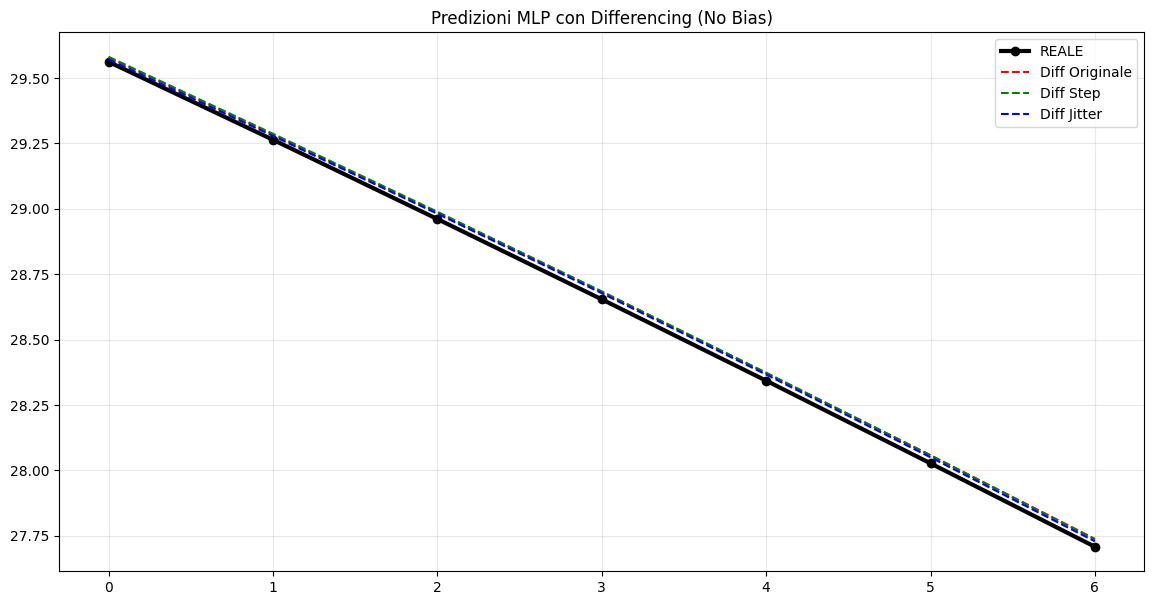

In [54]:
# Dizionario dataset differenziati
diff_sets = {
    "Diff Originale": (X_diff_orig, y_diff_orig),
    "Diff Step": (X_diff_step, y_diff_step),
    "Diff Jitter": (X_diff_jitter, y_diff_jitter)
}

results_diff = {}
metrics_diff = []
N_RUNS = 5 # Usiamo l'ensemble per stabilità

print("--- TRAINING SU DATI DIFFERENZIATI ---")

for name, (curr_X, curr_y) in diff_sets.items():
    print(f"\n>> Dataset: {name}")
    
    # Matrice per salvare le predizioni (Differenze)
    pred_diffs_all = np.zeros((N_RUNS, len(X_diff_test)))
    
    for i in range(N_RUNS):
        reset_seeds(seeds[i])
        # Usiamo lo STESSO modello MLP di prima
        model = build_mlp_model(WINDOW_SIZE) 
        
        model.fit(
            curr_X, curr_y,
            epochs=150,
            batch_size=16,
            validation_data=(X_diff_test, y_diff_test),
            verbose=0,
            callbacks=[early_stop, reduce_lr],
            shuffle=True
        )
        
        # Prediciamo la differenza scalata
        p_scaled = model.predict(X_diff_test, verbose=0)
        # Invertiamo lo scaling per avere la differenza reale (es. -0.4%)
        p_real_diff = scaler_diff.inverse_transform(p_scaled).flatten()
        pred_diffs_all[i, :] = p_real_diff

    # Media dell'Ensemble delle differenze
    avg_pred_diff = np.mean(pred_diffs_all, axis=0)
    
    # --- RICOSTRUZIONE (Cruciale) ---
    # Per ricostruire il valore al tempo T, prendiamo il valore REALE al tempo T-1
    # e aggiungiamo la differenza predetta.
    # y_test_vals[0:-1] sono i valori "precedenti" rispetto ai target
    # (Nota: stiamo usando sliding window sul test set reale)
    
    # Allineamento: X_diff_test inizia dopo WINDOW_SIZE passi del test set
    # Quindi ci servono i valori reali corrispondenti agli ultimi step di ogni finestra di input
    # Per semplicità: usiamo y_test_vals corrispondenti agli indici corretti
    
    # Recuperiamo i "valori precedenti" reali da cui sommare la differenza
    # Poiché diff perde 1 punto e window ne usa 5, dobbiamo allinearci bene.
    # Un modo robusto: 
    # y_test_real (quello usato nelle celle prima) parte da index (Window)
    # Il valore precedente a y_test_real[k] è y_test_vals[Window + k - 1]
    
    reconstructed_values = []
    # y_test_real è definito nelle celle precedenti (i target veri assoluti)
    for k in range(len(y_diff_test)):
        # Il valore vero precedente a quello che vogliamo predire
        prev_val_real = y_test_vals[WINDOW_SIZE + k] 
        # Predizione ricostruita = Precedente Reale + Differenza Predetta
        rec_val = prev_val_real + avg_pred_diff[k]
        reconstructed_values.append(rec_val)
        
    reconstructed_values = np.array(reconstructed_values)
    
    # Calcolo errore sui valori RICOSTRUITI
    # Nota: y_test_real[1:] perché la diff ci fa perdere un altro punto in output
    # Allineiamo le lunghezze:
    min_len = min(len(y_test_real), len(reconstructed_values))
    y_true_aligned = y_test_real[1:1+min_len] # Shift per allineare con la diff
    y_pred_aligned = reconstructed_values[:min_len]
    
    if len(y_true_aligned) > 0:
        rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
        mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
        
        results_diff[name] = y_pred_aligned
        metrics_diff.append({"Dataset": name, "RMSE": rmse, "MAE": mae})
        print(f"   RMSE Ricostruito: {rmse:.4f}")

# --- PLOT ---
df_res_diff = pd.DataFrame(metrics_diff).sort_values(by="RMSE")
display(df_res_diff)

plt.figure(figsize=(14, 7))
# Plot dei dati reali allineati
plt.plot(range(len(y_true_aligned)), y_true_aligned, 'o-', label='REALE', color='black', linewidth=3)

colors = ['red', 'green', 'blue']
for i, (name, preds) in enumerate(results_diff.items()):
    plt.plot(range(len(preds)), preds, '--', label=f'{name}', color=colors[i])

plt.title("Predizioni MLP con Differencing (No Bias)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()